### QQP with LMU


In [3]:
from __future__ import annotations
from typing import Dict, Any

import torch
from pathlib import Path

from qqp_task import QQPTask
from src.train_utils.trainer import Trainer

### Configuration

We define hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory for consistent configuration.

In [4]:
from src.utils.block_factory import make_lmu_block_cfg_ctor

In [5]:
from src.utils.common import device_auto

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "qqp" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 256,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_len": 64,
        "max_vocab": 50_000,
        "min_freq": 2,
        "lowercase": True,
        "val_ratio": 0.1,
        "test_ratio": 0.1,
        "pin_memory": False,
        "persistent_workers": False,
        "seed": 42,
    },

    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/qqp_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # QQP specific
    "max_len": 64,
}

args["block_cfg_ctor"] = make_lmu_block_cfg_ctor(
   **args,
)

args = device_auto(args)

Using MPS


### Training

With the configuration set up, we instantiate the `QQPTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [6]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = QQPTask()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

### Visualization

Load the best checkpoint and visualize the training history.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 35
Val metrics: {'loss': 0.47544479409254153, 'time_s': 9.953086165999594, 'acc': 0.7825151477886599}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

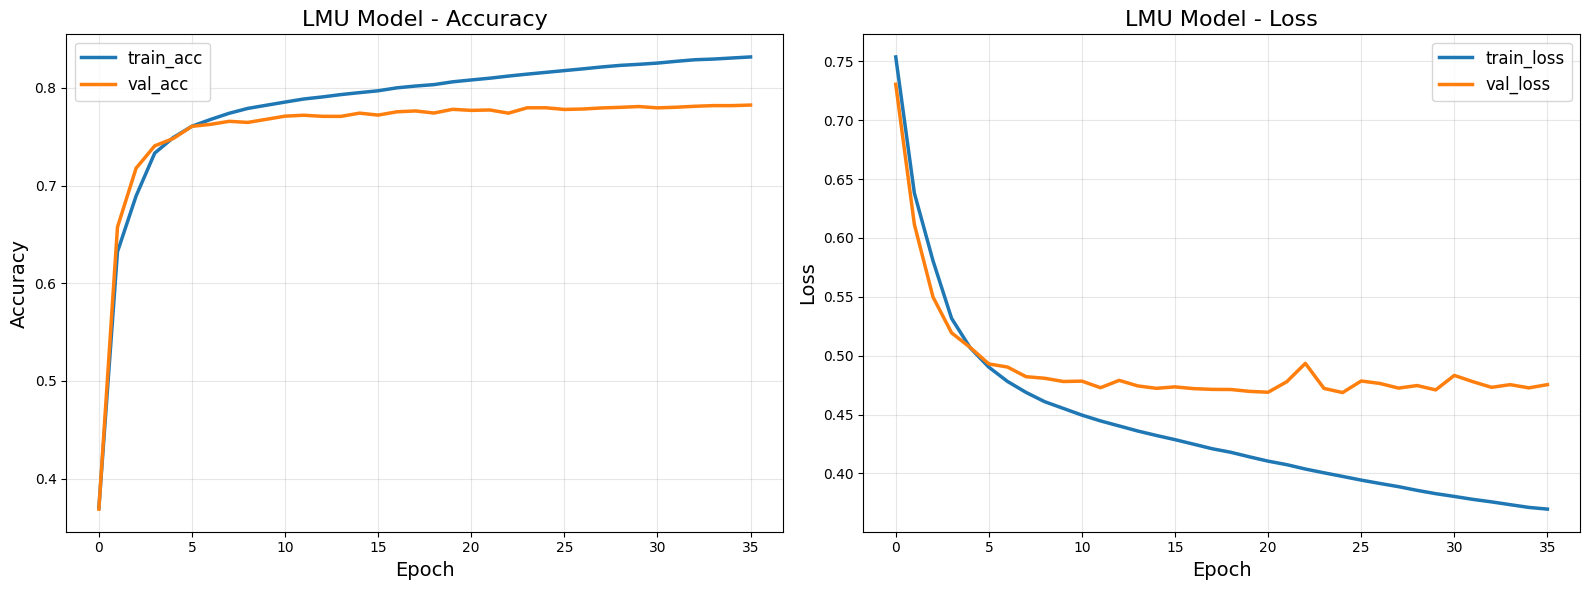


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: LMUCoreAdapter
Number of Blocks: 1

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:              6,468,611
Trainable parameters:          6,468,611
Non-trainable parameters:              0
Model size (MB):                   24.68

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
embedding                      Embedding                       6,318,976
blocks                         ModuleList

In [8]:
from src.utils.common import print_model_details
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=QQPTask(),
)

history = trainer.history

plot_history(history, model_name="LMU")

print_model_details(model=trainer.model)

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=QQPTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=2,
    use_test_set=True,
    additional_metrics=['precision', 'recall', 'pr_auc', 'roc_auc', 'f1_score'],
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/qqp_lmu_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=QQPTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=QQPTask(),
        best_model_path=best_path,
        num_classes=2,
        use_test_set=True,
        additional_metrics=['precision', 'recall', 'pr_auc', 'roc_auc', 'f1_score'],
    )